In [2]:
# ============================================================
# Cell 1: Imports & Setup
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import warnings, random, time, os
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

try:
    from numba import cuda, jit, prange
    GPU_AVAILABLE = cuda.is_available()
except:
    GPU_AVAILABLE = False
    from numba import jit, prange

print(f"{'='*70}")
print(f"SiO₂-CaO-P₂O₅ Ternary NPT Monte Carlo | {'GPU' if GPU_AVAILABLE else 'CPU'}")
print(f"{'='*70}")

SiO₂-CaO-P₂O₅ Ternary NPT Monte Carlo | CPU


In [3]:
# ============================================================
# Cell 2: Physical Constants & BKS + Phosphate/Ca Potentials
# ============================================================
K_B = 8.617333262145e-5       # eV/K
COULOMB_CONST = 14.39964547842567  # eV·Å/e²
ATM_TO_EV_A3 = 6.242e-7        # atm → eV/Å³
MIN_DIST = 0.8                  # حداقل فاصله مجاز (Å)
HARD_REPULSION = 1000.0         # قدرت دفع سخت

# ===== BKS + Phosphate Potentials =====
# Type mapping: 0=O, 1=Si, 2=Ca, 3=P
# Buckingham: V(r) = A·exp(-r/ρ) - C/r⁶

BUCK_A = np.array([
    [2029.2204, 13702.905, 7747.1834, 26655.472],    # O-X
    [13702.905, 0.0,       0.0,       0.0],           # Si-X (only Si-O)
    [7747.1834, 0.0,       0.0,       0.0],           # Ca-X (only Ca-O)
    [26655.472, 0.0,       0.0,       0.0],           # P-X (only P-O)
], dtype=np.float64)

BUCK_RHO = np.array([
    [0.343645, 0.193817, 0.252623, 0.181968],    # O-X
    [0.193817, 1.0,      1.0,      1.0],          # Si-X
    [0.252623, 1.0,      1.0,      1.0],          # Ca-X
    [0.181968, 1.0,      1.0,      1.0],          # P-X
], dtype=np.float64)

BUCK_C = np.array([
    [192.58, 54.681,  93.109,  86.856],    # O-X
    [54.681, 0.0,      0.0,      0.0],      # Si-X
    [93.109, 0.0,      0.0,      0.0],      # Ca-X
    [86.856, 0.0,      0.0,      0.0],      # P-X
], dtype=np.float64)

# Partial charges: O=-1.2, Si=+2.4, Ca=+1.2, P=+3.0
CHARGES = np.array([-1.2, 2.4, 1.2, 3.0], dtype=np.float64)

CUTOFF = 10.0
SKIN = 2.0
NEIGH_CUT = CUTOFF + SKIN

print("✓ BKS + Phosphate potentials loaded")
print(f"  Si⁺²·⁴-O⁻¹·²: A=13702.9, ρ=0.1938, C=54.68")
print(f"  Ca⁺¹·²-O⁻¹·²: A=7747.2, ρ=0.2526, C=93.11")
print(f"  P⁺³·⁰-O⁻¹·²:  A=26655.5, ρ=0.1820, C=86.86")
print(f"  O⁻¹·²-O⁻¹·²:  A=2029.2, ρ=0.3436, C=192.58")

✓ BKS + Phosphate potentials loaded
  Si⁺²·⁴-O⁻¹·²: A=13702.9, ρ=0.1938, C=54.68
  Ca⁺¹·²-O⁻¹·²: A=7747.2, ρ=0.2526, C=93.11
  P⁺³·⁰-O⁻¹·²:  A=26655.5, ρ=0.1820, C=86.86
  O⁻¹·²-O⁻¹·²:  A=2029.2, ρ=0.3436, C=192.58


In [4]:
# ============================================================
# Cell 3: Simulation Parameters
# ============================================================
N_STEPS = 5000              # ۵۰۰۰ گام مونت کارلو
T_START = 5000.0            # دمای شروع (ذوب)
T_END = 300.0               # دمای پایان
P_TARGET = 1.0              # فشار هدف (atm)
BOX_INIT = 30.0             # حجم باکس ۳۰ آنگستروم
MAX_DISP = 0.15             # گام جابجایی اولیه

XYZ_OUTPUT_FREQ = 1000      # خروجی XYZ هر ۱۰۰۰ گام
HISTORY_FREQ = 50           # ثبت تاریخچه هر ۵۰ گام
NEIGH_UPDATE = 100          # بازسازی لیست همسایگی
DISP_ADJUST = 500           # تنظیم خودکار گام

TARGET_ACC = 0.40
ACC_TOL = 0.10
BOX_MIN = 20.0
BOX_MAX = 45.0

print(f"✓ NPT Simulation: {N_STEPS} steps, {T_START}K→{T_END}K")
print(f"  Box: {BOX_INIT} Å, P: {P_TARGET} atm")

✓ NPT Simulation: 5000 steps, 5000.0K→300.0K
  Box: 30.0 Å, P: 1.0 atm


In [5]:
# ============================================================
# Cell 4: Energy Function (Numba JIT)
# ============================================================
@jit(nopython=True, fastmath=True, parallel=True)
def energy_cpu(coords, types, neigh, cnt, box):
    """محاسبه انرژی کل با پتانسیل BKS + فسفات"""
    n = len(coords); e = 0.0; half = box / 2.0
    for i in prange(n):
        xi, yi, zi = coords[i]; ti = types[i]; qi = CHARGES[ti]
        for idx in range(cnt[i]):
            j = neigh[i, idx]
            if j <= i: continue
            dx = xi - coords[j,0]; dy = yi - coords[j,1]; dz = zi - coords[j,2]
            if dx > half: dx -= box
            elif dx < -half: dx += box
            if dy > half: dy -= box
            elif dy < -half: dy += box
            if dz > half: dz -= box
            elif dz < -half: dz += box
            r = (dx*dx + dy*dy + dz*dz) ** 0.5
            if r < MIN_DIST: e += HARD_REPULSION*(MIN_DIST-r); continue
            if r >= CUTOFF: continue
            tj = types[j]
            A, rho, C = BUCK_A[ti,tj], BUCK_RHO[ti,tj], BUCK_C[ti,tj]
            eb = A * np.exp(-r/rho) - C/(r**6) if A > 0 else 0.0
            damp = 1.0 - np.exp(-0.5*r)
            e += eb + COULOMB_CONST * qi * CHARGES[tj] * damp / r
    return e

def build_neighbors(coords, box, cutoff):
    """ساخت لیست همسایگی با شرط مرزی دوره‌ای"""
    tree = cKDTree(coords, boxsize=box)
    pairs = tree.query_pairs(r=cutoff, output_type='ndarray')
    n = len(coords); neigh = [[] for _ in range(n)]
    for i, j in pairs: neigh[i].append(j); neigh[j].append(i)
    max_n = max(len(nl) for nl in neigh) if n > 0 else 0
    arr = np.full((n, max_n), -1, dtype=np.int32)
    cnt = np.zeros(n, dtype=np.int32)
    for i in range(n):
        cnt[i] = len(neigh[i])
        if cnt[i] > 0: arr[i, :cnt[i]] = neigh[i]
    return arr, cnt

def compute_cn(coords, types, box, type_i, type_j, r_cut=2.6):
    """محاسبه عدد کئوردیناسیون بین دو نوع اتم"""
    idx_i = np.where(types == type_i)[0]
    if len(idx_i) == 0: return 0.0
    tree = cKDTree(coords, boxsize=box)
    return np.mean([sum(1 for n in tree.query_ball_point(coords[i], r_cut) if types[n] == type_j) for i in idx_i])

def get_density(coords, box):
    """چگالی کل (g/cm³) - تقریبی برای سیستم سه‌جزئی"""
    n_total = len(coords)
    # میانگین وزن اتمی تقریبی
    avg_mass = 40.0  # g/mol (میانگین SiO₂-CaO-P₂O₅)
    return n_total * avg_mass / (6.022e23 * box**3) * 1e24

print("✓ Energy functions compiled")

✓ Energy functions compiled


In [6]:
# ============================================================
# Cell 5: MC Moves
# ============================================================
def move_atom(coords, types, box, e_cur, T, neigh, cnt, max_d):
    """جابجایی تصادفی یک اتم"""
    i = random.randrange(len(coords))
    old = coords[i].copy()
    coords[i] = (coords[i] + np.random.uniform(-max_d, max_d, 3)) % box
    e_new = energy_cpu(coords, types, neigh, cnt, box)
    de = e_new - e_cur
    if de <= 0 or random.random() < np.exp(-de/(K_B*T)):
        return True, e_new
    coords[i] = old
    return False, e_cur

def move_volume(coords, box, types, e_cur, T, P, neigh, cnt):
    """تغییر حجم ایزوتروپیک (NPT)"""
    n = len(coords)
    sc = np.exp(0.001 * (2*random.random() - 1))  # تغییر ۰.۱٪
    nb = box * sc
    if nb < BOX_MIN or nb > BOX_MAX:
        return coords, box, e_cur, False, neigh, cnt
    nc = coords * sc
    nn, ncnt = build_neighbors(nc, nb, NEIGH_CUT)
    ne = energy_cpu(nc, types, nn, ncnt, nb)
    dE = ne - e_cur; dV = nb**3 - box**3
    dH = dE + P*ATM_TO_EV_A3*dV - n*K_B*T*np.log(sc**3)
    if dH <= 0 or random.random() < np.exp(-dH/(K_B*T)):
        return nc, nb, ne, True, nn, ncnt
    return coords, box, e_cur, False, neigh, cnt

print("✓ MC moves ready")

✓ MC moves ready


In [7]:
# ============================================================
# Cell 6: Load Ternary Structure
# ============================================================
print("📂 Loading Ternary.txt...")

# خوندن فایل ساختار سه‌جزئی
with open("Ternary.txt", 'r') as f:
    lines = f.readlines()

n_atoms = int(lines[0].strip())
print(f"   Total atoms: {n_atoms}")

coords_list = []; types_list = []
atom_to_type = {'Si': 1, 'O': 0, 'Ca': 2, 'P': 3}

for line in lines[2:2+n_atoms]:
    parts = line.strip().split()
    if len(parts) >= 4:
        atom_type = parts[0]
        x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
        types_list.append(atom_to_type.get(atom_type, 0))
        coords_list.append([x, y, z])

coords = np.array(coords_list)
types = np.array(types_list, dtype=np.int32)

# تنظیم باکس ۳۰ آنگستروم
box = BOX_INIT
coords = coords % box

n_Si = np.sum(types == 1)
n_O = np.sum(types == 0)
n_Ca = np.sum(types == 2)
n_P = np.sum(types == 3)

print(f"   Si: {n_Si}, O: {n_O}, Ca: {n_Ca}, P: {n_P}")
print(f"   Box: {box} Å, Density: {get_density(coords, box):.3f} g/cm³")

📂 Loading Ternary.txt...
   Total atoms: 1960
   Si: 420, O: 1232, Ca: 252, P: 56
   Box: 30.0 Å, Density: 4.822 g/cm³


In [8]:
# ============================================================
# Cell 7: Run NPT Monte Carlo
# ============================================================
print(f"\n🚀 Starting NPT-MC: {T_START}K → {T_END}K, {N_STEPS} steps")

# مقداردهی اولیه
neigh, cnt = build_neighbors(coords, box, NEIGH_CUT)
e_current = energy_cpu(coords, types, neigh, cnt, box)

energy_history = []; temp_history = []; box_history = []
accepted = 0; best_e = e_current
best_coords = coords.copy(); best_box = box
max_disp = MAX_DISP

trajectory_frames = []
rho_init = get_density(coords, box)
print(f"   Initial: E={e_current:.1f} eV, Box={box:.2f} Å, ρ≈{rho_init:.3f} g/cm³\n")

pbar = tqdm(range(1, N_STEPS+1), desc="NPT-MC", unit="step")
start_time = time.time()

for step in pbar:
    # برنامه دمایی: خنک شدن نمایی
    progress = step / N_STEPS
    T = T_END + (T_START - T_END) * np.exp(-3.0 * progress)
    
    # انتخاب نوع حرکت
    if step % 50 == 0:  # تغییر حجم هر ۵۰ گام
        coords, box, e_current, ok, neigh, cnt = move_volume(
            coords, box, types, e_current, T, P_TARGET, neigh, cnt)
    else:
        ok, e_current = move_atom(coords, types, box, e_current, T, neigh, cnt, max_disp)
        if ok: accepted += 1
    
    # ذخیره‌سازی
    if step % HISTORY_FREQ == 0:
        energy_history.append(e_current)
        temp_history.append(T)
        box_history.append(box)
        if e_current < best_e:
            best_e = e_current
            best_coords = coords.copy()
            best_box = box
    
    # بازسازی لیست همسایگی
    if step % NEIGH_UPDATE == 0:
        neigh, cnt = build_neighbors(coords, box, NEIGH_CUT)
        e_current = energy_cpu(coords, types, neigh, cnt, box)
    
    # تنظیم خودکار گام
    if step % DISP_ADJUST == 0 and step > 0:
        ar = accepted / DISP_ADJUST
        if ar < TARGET_ACC - ACC_TOL: max_disp *= 0.95
        elif ar > TARGET_ACC + ACC_TOL: max_disp *= 1.05
        max_disp = max(0.02, min(max_disp, 0.5))
        accepted = 0
    
    # ذخیره فریم
    if step % XYZ_OUTPUT_FREQ == 0:
        trajectory_frames.append({
            'coords': coords.copy(), 'box': box, 'step': step,
            'energy': e_current, 'T': T
        })
    
    # بروزرسانی progress bar
    if step % 100 == 0:
        acc_rate = accepted / min(step, DISP_ADJUST) * 100
        pbar.set_postfix({'T': f'{T:.0f}K', 'E': f'{e_current:.0f}', 
                         'box': f'{box:.2f}', 'acc': f'{acc_rate:.0f}%'})

pbar.close()
elapsed = time.time() - start_time
print(f"\n✅ Done in {elapsed:.1f}s | Best E: {best_e:.0f} eV | Final Box: {best_box:.3f} Å")


🚀 Starting NPT-MC: 5000.0K → 300.0K, 5000 steps
   Initial: E=-10878.6 eV, Box=30.00 Å, ρ≈4.822 g/cm³



NPT-MC:   0%|          | 0/5000 [00:00<?, ?step/s]


✅ Done in 64.7s | Best E: -20489 eV | Final Box: 30.044 Å


📊 Generating analysis...

RESULTS SUMMARY
  Final Energy:     -20,489.3 eV
  Final Box:        30.044 Å
  Approx Density:   4.801 g/cm³

  Coordination Numbers:
    Si-O:  4.00 (target: 4.0)
    Ca-O:  3.98 (target: 6-8)
    P-O:   4.00 (target: 4.0)


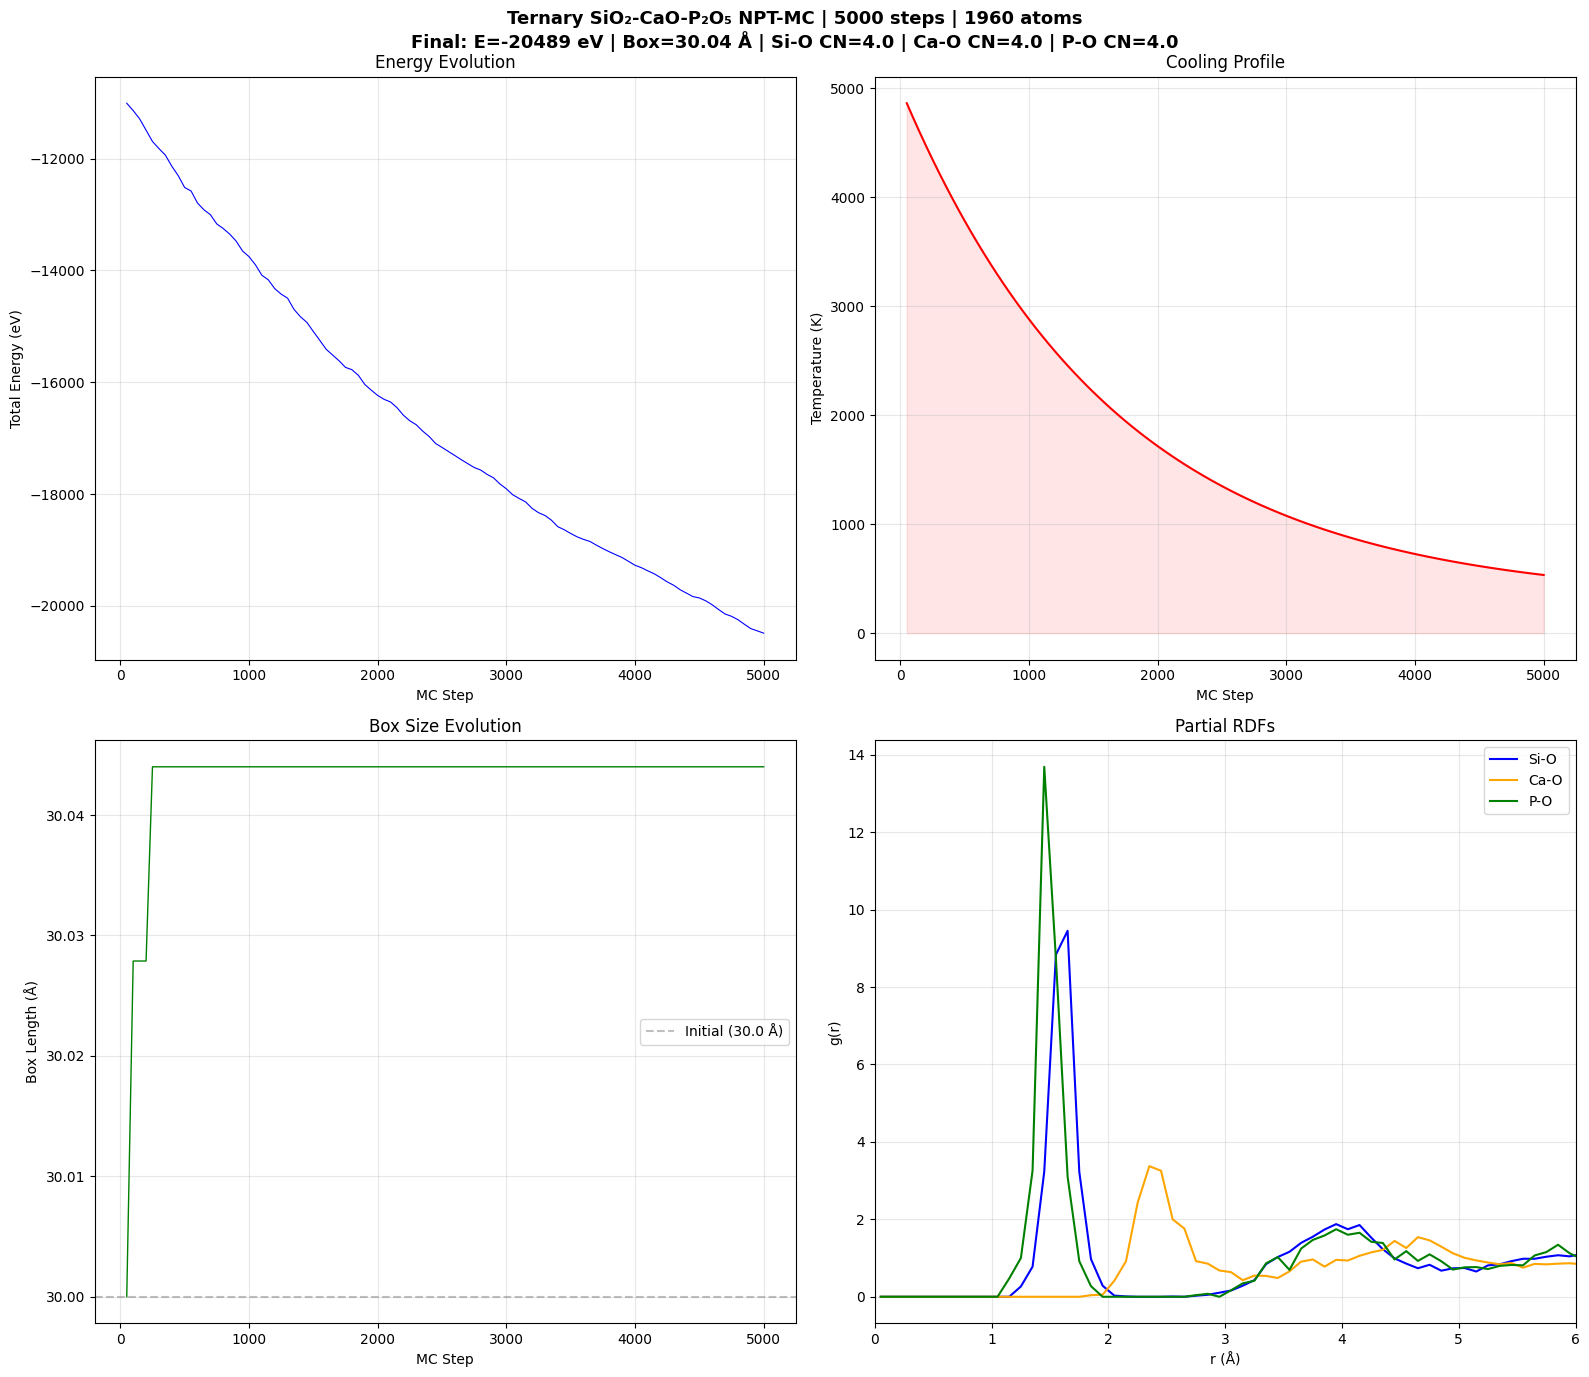

✓ Plot saved to ternary_analysis.png


In [9]:
# ============================================================
# Cell 8: Analysis & Plots
# ============================================================
print("📊 Generating analysis...")

# ===== RDF =====
def compute_rdf(coords, types, box, type_i, type_j, dr=0.1, rmax=8.0):
    """RDF جزئی برای جفت اتم‌های خاص"""
    idx_i = np.where(types == type_i)[0]
    idx_j = np.where(types == type_j)[0] if type_i != type_j else idx_i
    
    n_i = len(idx_i); n_j = len(idx_j)
    if n_i == 0 or n_j == 0: return np.arange(0, rmax, dr), np.zeros(int(rmax/dr))
    
    rho_j = n_j / box**3
    bins = int(rmax/dr); hist = np.zeros(bins)
    
    tree = cKDTree(coords, boxsize=box)
    for i in idx_i:
        neighbors = tree.query_ball_point(coords[i], rmax)
        for j in neighbors:
            if types[j] == type_j and (type_i != type_j or i != j):
                rvec = coords[i] - coords[j]
                rvec = rvec - box * np.round(rvec/box)
                r = np.sqrt(np.sum(rvec**2))
                if r < rmax:
                    idx = int(r/dr)
                    if idx < bins: hist[idx] += 1
    
    rv = (np.arange(bins) + 0.5) * dr
    sv = 4 * np.pi * rv**2 * dr
    with np.errstate(divide='ignore', invalid='ignore'):
        g = np.where(sv > 0, hist / (n_i * rho_j * sv), 0.0)
    return rv, g

# ===== محاسبه RDFها =====
r_sio, g_sio = compute_rdf(best_coords, types, best_box, 1, 0)  # Si-O
r_cao, g_cao = compute_rdf(best_coords, types, best_box, 2, 0)  # Ca-O
r_po, g_po = compute_rdf(best_coords, types, best_box, 3, 0)    # P-O

# ===== کئوردیناسیون‌ها =====
cn_si_o = compute_cn(best_coords, types, best_box, 1, 0)  # Si-O
cn_ca_o = compute_cn(best_coords, types, best_box, 2, 0)  # Ca-O
cn_p_o = compute_cn(best_coords, types, best_box, 3, 0)   # P-O

# ===== چگالی نهایی =====
rho_final = get_density(best_coords, best_box)

print(f"\n{'='*60}")
print(f"RESULTS SUMMARY")
print(f"{'='*60}")
print(f"  Final Energy:     {best_e:,.1f} eV")
print(f"  Final Box:        {best_box:.3f} Å")
print(f"  Approx Density:   {rho_final:.3f} g/cm³")
print(f"\n  Coordination Numbers:")
print(f"    Si-O:  {cn_si_o:.2f} (target: 4.0)")
print(f"    Ca-O:  {cn_ca_o:.2f} (target: 6-8)")
print(f"    P-O:   {cn_p_o:.2f} (target: 4.0)")
print(f"{'='*60}")

# ===== نمودارها =====
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Energy evolution
steps_plot = np.arange(1, len(energy_history)+1) * HISTORY_FREQ
axes[0,0].plot(steps_plot, energy_history, 'b-', lw=0.8)
axes[0,0].set(xlabel='MC Step', ylabel='Total Energy (eV)', title='Energy Evolution')
axes[0,0].grid(alpha=0.3)

# Temperature
axes[0,1].plot(steps_plot, temp_history, 'r-', lw=1.5)
axes[0,1].fill_between(steps_plot, 0, temp_history, alpha=0.1, color='red')
axes[0,1].set(xlabel='MC Step', ylabel='Temperature (K)', title='Cooling Profile')
axes[0,1].grid(alpha=0.3)

# Box size
axes[1,0].plot(steps_plot, box_history, 'g-', lw=1)
axes[1,0].axhline(BOX_INIT, color='gray', ls='--', alpha=0.5, label=f'Initial ({BOX_INIT} Å)')
axes[1,0].set(xlabel='MC Step', ylabel='Box Length (Å)', title='Box Size Evolution')
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

# RDFs
axes[1,1].plot(r_sio, g_sio, 'b-', lw=1.5, label='Si-O')
axes[1,1].plot(r_cao, g_cao, 'orange', lw=1.5, label='Ca-O')
axes[1,1].plot(r_po, g_po, 'green', lw=1.5, label='P-O')
axes[1,1].set(xlabel='r (Å)', ylabel='g(r)', title='Partial RDFs', xlim=(0, 6))
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

plt.suptitle(f'Ternary SiO₂-CaO-P₂O₅ NPT-MC | {N_STEPS} steps | {n_atoms} atoms\n'
             f'Final: E={best_e:.0f} eV | Box={best_box:.2f} Å | '
             f'Si-O CN={cn_si_o:.1f} | Ca-O CN={cn_ca_o:.1f} | P-O CN={cn_p_o:.1f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("ternary_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved to ternary_analysis.png")

In [10]:
# ============================================================
# Cell 9: Save Final Structure
# ============================================================
type_names = {0: 'O', 1: 'Si', 2: 'Ca', 3: 'P'}

with open("ternary_final.xyz", 'w') as f:
    f.write(f"{len(best_coords)}\n")
    f.write(f"Ternary SiO2-CaO-P2O5 NPT-MC {N_STEPS}steps "
            f"E={best_e:.1f}eV Box={best_box:.3f}A\n")
    for i in range(len(best_coords)):
        sym = type_names[types[i]]
        f.write(f"{sym} {best_coords[i,0]:.6f} {best_coords[i,1]:.6f} {best_coords[i,2]:.6f}\n")

print(f"✓ Final structure saved to ternary_final.xyz")

# Save trajectory
with open("ternary_trajectory.xyz", 'w') as f:
    for idx, frame in enumerate(trajectory_frames):
        f.write(f"{len(frame['coords'])}\n")
        f.write(f"Frame {idx+1} Step={frame['step']} T={frame['T']:.0f}K "
                f"E={frame['energy']:.1f}eV Box={frame['box']:.3f}A\n")
        for i in range(len(frame['coords'])):
            sym = type_names[types[i]]
            f.write(f"{sym} {frame['coords'][i,0]:.6f} {frame['coords'][i,1]:.6f} {frame['coords'][i,2]:.6f}\n")

print(f"✓ Trajectory saved to ternary_trajectory.xyz ({len(trajectory_frames)} frames)")

✓ Final structure saved to ternary_final.xyz
✓ Trajectory saved to ternary_trajectory.xyz (5 frames)
